In [1]:
from myclass import *

In [2]:

# warnings.filterwarnings("ignore", category=DeprecationWarning) 
# warnings.filterwarnings('ignore')

#################################################
#------------------ Load Data ------------------#
#################################################

patient_info = pd.read_excel('Dataset.xlsx','patient_information',engine='openpyxl')
cnv_5mb_counts = pd.read_excel('Dataset.xlsx','cnv_5mb_counts',engine='openpyxl').loc[:,['patientID','cnv_Count']].rename(columns={'cnv_Count': 'cnv_Count_5mb'})
cnv_gistic_counts = pd.read_excel('Dataset.xlsx','cnv_gistic_counts',engine='openpyxl').loc[:,['patientID','cnv_Count']].rename(columns={'cnv_Count': 'cnv_Count_gistic'})
snv = pd.read_excel('Dataset.xlsx','snv_feature_matrix',engine='openpyxl')
clinical_info = pd.read_excel('Clinical Feature.xlsx','Supplementary Table 2',engine='openpyxl').drop(['Subject type', 'Subject group', 'Stage (AJCC v7)', 'Pack-years'], axis=1)
clinical_info = clinical_info.rename(columns={'Histology':'Histology label'})

In [3]:
import os
os.environ['CUDA_LAUNCH_BLOCKING'] = "1"

seed = 1105
random.seed(seed)
os.environ['PYTHONHASHSEED'] = str(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

## Data

In [4]:
##################################################
#-------------- Data Preprocessing -------------#
################################################

#----- Parameters -----#
num_patients_train = len(patient_info[patient_info.split_info == 'training'])# number of patients in training set
num_patients_test = len(patient_info[patient_info.split_info == 'validation'])# number of patients in training set
max_variats = 84 # max number of variation for each patient
num_steps = max_variats
num_feature_not_snv = 8
num_var_attri = snv.shape[1] # number of attributes to discribe each variation
scale = Normalization('MinMaxLogScale') # choose normalizer

#----- OneHot categorical variable of SNV-----#
snv['gene'] = deepcopy(snv['Gene']) # prepare for gene_snv
one_hot,_,_ = OneHotText(snv['Gene'])
snv['Gene'] = [one_hot[i] for i in range(len(one_hot))]

one_hot,_,_ = OneHotText(snv['Variant.type'])
snv['Variant.type'] = [one_hot[i] for i in range(len(one_hot))]
len_feature = {'Variant.type': len(one_hot[0])}

snv['BaseConversion'] = snv['Tumor.allele']+snv['Ref..allele']
one_hot,_,_ = OneHotText(snv['BaseConversion'])
snv['BaseConversion'] = [one_hot[i] for i in range(len(one_hot))]
len_feature['BaseConversion'] = len(one_hot[0])

one_hot,_,_ = OneHotText(snv['Chr'])
snv['Chr'] = [one_hot[i] for i in range(len(one_hot))]
len_feature['Chr'] = len(one_hot[0])

one_hot,_,_ = OneHotText(snv['germline_reads'])
snv['germline_reads'] = [one_hot[i] for i in range(len(one_hot))]
len_feature['germline_reads'] = len(one_hot[0])

# drop coded feature
snv = snv.drop(['Tumor.allele', 'Ref..allele', 'variant', 'lookup', 
                'Case', 'cohort', 'A>CUnstranded', 'A>GUnstranded',
                'A>TUnstranded', 'C>AUnstranded', 'C>GUnstranded', 
                'G>AUnstranded', 'pass_basic_QC', 'blacklist1_oncogenes',
                'pass_basic_QC_coding'], axis=1)

# snv feature list to scale
list_to_normalization = ['Position','Percent.mutant.allele', 'variant_count_norm','ontarget_shoulder_tile_mut_count_norm', 
                         'duplex_reads', 'germline_NumNonZeroMeanAF_Pval', 'mean_bc_family_size', 'watsoncrickfisher.p',
                         'mean_total_bc_errors_corrected', 'mean_norm_varpos', 'mean_var_phred_score', 'mean_num_non_ref_bases',
                         'fraction_MapQmin30', 'variant_norm_bc_fam_size', 'normalized_depth','gnomad_maxAF',
                         'size_selected_adjustment','germlinebg_Bayesian_pval', 'cfdnabg_Bayesian_pval',
                         'sum_log10_frag_size_enrich_score', 'germline_depth_at_position', 'cosmic_total_count', 'cosmic_lung_count']

In [5]:
#----- OneHot categorical variable of clinical features ----#
one_hot,_,_ = OneHotText(clinical_info['Sex'])
clinical_info['Sex'] = deepcopy(one_hot)

one_hot,_,_ = OneHotText(clinical_info['Histology label'])
clinical_info['Histology label'] = deepcopy(one_hot)

one_hot,_,_ = OneHotText(clinical_info['Smoker'])
clinical_info['Smoker'] = deepcopy(one_hot)

In [6]:
x = patient_info.set_index('patientID').\
join(cnv_5mb_counts.set_index('patientID')).join(cnv_gistic_counts.set_index('patientID')).drop('SampleID', axis=1).\
join(clinical_info.set_index('Patient ID'))
num_patients = len(x)

In [7]:
#----- snv normalization -----#
snv_group = np.array(snv.drop(['Gene'], axis=1).groupby('patientID'),dtype = object)
list_gene = unique(snv['gene'])
gene_snv_columns = ['Variant.type', 'Chr', 'Position', 'Percent.mutant.allele', 'variant_count_norm',
       'ontarget_shoulder_tile_mut_count_norm', 'pass_split_1yes',
       'duplex_reads', 'germline_NumNonZeroMeanAF_Pval',
       'mean_bc_family_size', 'watsoncrickfisher.p',
       'mean_total_bc_errors_corrected', 'mean_norm_varpos',
       'mean_var_phred_score', 'mean_num_non_ref_bases',
       'fraction_MapQmin30', 'variant_norm_bc_fam_size',
       'normalized_depth', 'gnomad_maxAF', 'base_change_transition',
       'size_selected_adjustment', 'LUNG_driver',
       'pass_basic_QC_nonsynon_lungdriver',
       'pass_basic_QC_nonsynon_lungdriver_hotspot',
       'germlinebg_Bayesian_pval', 'cfdnabg_Bayesian_pval',
       'sum_log10_frag_size_enrich_score', 'germline_reads',
       'germline_depth_at_position', 'tumor_adjudicated',
       'cosmic_total_count', 'has_matched_tumor',
       'intersect_unpadded_selector', 'cosmic_lung_count',
       'blacklist3tumorsupressor', 'BaseConversion']

zero_snv_feature = []
for i in gene_snv_columns:
    if i in len_feature.keys():
        zero_snv_feature.append([0 for _ in range(len_feature[i])])
    else:
        zero_snv_feature.append(0)
zero_snv_feature = [zero_snv_feature for i in range(len(list_gene))]

x['gene_snv'] = [pd.DataFrame(zero_snv_feature, index=list_gene, columns=gene_snv_columns) for i in range(num_patients)] # fill snv with 0

for i in range(len(snv_group)):
    patient_id = snv_group[i][0]
    # count and check the snv for each gene
    count = Counter(snv_group[i][1]['gene'])
    count = pd.DataFrame(count,index=['frequency']).T
    if any(count['frequency'] > 1):
        gene = count.index[count['frequency'] > 1]
        # reserve the snv with highest 'Percent.mutant.allele'
        for j in range(len(gene)):
            index_repeat_gene = snv_group[i][1]['gene'] == gene[j]
            index_to_drop = argsort(snv_group[i][1][index_repeat_gene]['Percent.mutant.allele']).index[1:]
            snv_group[i][1] = snv_group[i][1].drop(index = index_to_drop)  
    # fill the snv with gene_snv_feature
    gene_snv = snv_group[i][1]['gene']
    gene_snv_feature = snv_group[i][1].drop(['patientID', 'gene'], axis=1)
    x.loc[patient_id,'gene_snv'].loc[gene_snv] = gene_snv_feature.values

x['gene_snv_matrix']= [FlattenSNV(x['gene_snv'][i]) for i in range(num_patients)] 
# x['gene_snv_matrix']= [np.column_stack((FlattenSNV(x['gene_snv'][i]),np.zeros(192))) for i in range(num_patients)]    
snv = snv.drop('gene', axis=1)

In [8]:
##################################################
#-------------- Obtain Training Set -------------#
################################################
train_x = deepcopy(x[x.split_info == 'training'])

#----- clinical features normalization -----#
clinical_list_to_normalization = ['Age (years)', 'Plasma volume used', 'Plasma cfDNA concentration (ng/mL)', 'Plasma DNA input (ng)']
train_x = normalizer(train_x, clinical_list_to_normalization, scale)
#----- cnv normalization -----#
cnv_list_to_normalization = ['cnv_Count_5mb','cnv_Count_gistic']
train_x = normalizer(train_x, cnv_list_to_normalization, scale)
#----- snv normalization -----#
train_snv = deepcopy(snv[['SU2'not in i for i in snv['patientID']]])
train_snv = normalizer(train_snv, list_to_normalization, scale)
train_x = GroupAndExtractSNV(train_x, train_snv, num_steps)
    
#----- Label -----#    
train_x['label'] = [1 if 'LUP' in train_x.index[i] else 0 for i in range(train_x.shape[0])]
one_hot,_,_ = OneHotText(train_x['Stage_group'])
train_x['stage_label'] = [one_hot[i] for i in range(len(one_hot))]
train_x = train_x.drop(['Stage_group'], axis=1)

In [9]:
##################################################
#-------------- Obtain Test Set -------------#
################################################

test_x = deepcopy(x[x.split_info == 'validation'])

#----- clinical features normalization -----#
test_x = normalizer(test_x, clinical_list_to_normalization, scale)
#----- cnv normalization -----#
test_x = normalizer(test_x, cnv_list_to_normalization, scale)
#----- snv normalization -----#
test_snv = deepcopy(snv[['SU2' in i for i in snv['patientID']]])
test_snv = normalizer(test_snv, list_to_normalization, scale)
test_x = GroupAndExtractSNV(test_x, test_snv, num_steps)
    
#----- Label -----#    
test_x['label'] = [1 if 'SU2CS' in test_x.index[i] else 0 for i in range(test_x.shape[0])]
one_hot,_,_ = OneHotText(test_x['Stage_group'])
test_x['stage_label'] = [one_hot[i] for i in range(len(one_hot))]
test_x = test_x.drop(['Stage_group'], axis=1)

In [10]:
train_x_org = deepcopy(train_x)
test_x_org = deepcopy(test_x)

# AutoML based on Baysian optimization

In [11]:
class AutoTransformer(nn.Module):
    """
    Class description: only Dropout on LSTM & FC no batch norm, bidirectional Long Short-term memory model
    
    """
    #----- Define all layers -----#
    def __init__(self, fc_dropout, num_feature_not_snv, num_output_nodes, num_fc_layers, device, 
                 head, trsf_num_layer, trsf_dropout, trsf_hidden, shape, act = nn.Sigmoid(), **kwargs):
        super(AutoTransformer, self).__init__(**kwargs)
        
        #--- Transformer ---#
        # TOD0: trsf_hidden_dim
        len_sentence,trsf_imput_dim, trsf_hidden_dim  = shape[0], shape[1], trsf_hidden*head
        
        self.attention_model = AttentionModel(d_input=trsf_imput_dim, d_model=trsf_hidden_dim, d_ff=2*trsf_hidden_dim, head=head, 
                                              num_layer=trsf_num_layer, dropout=trsf_dropout)
        self.trsf_fc = nn.Linear(trsf_hidden_dim, 1)        
        
        for p in self.attention_model.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)     
        
        #--- Fully connected layers ---#
        self.num_fc_layers = num_fc_layers
        num_fc_input =  num_feature_not_snv+len_sentence
        if num_fc_layers == 1:
            self.fc0 = nn.Linear(num_fc_input, num_output_nodes)
        else:
            # the first fc layer
            self.fc0 = nn.Linear(num_fc_input, int(ceil(num_fc_input/2)))
            self.dropout0 = nn.Dropout(1.1*fc_dropout)
            if num_fc_layers == 2:
                # the last fc layer when num_fc_layers == 2
                self.fc1 = nn.Linear(int(ceil(num_fc_input/2)), num_output_nodes)
            else:
                # the middle fc layer
                for i in range(1,num_fc_layers-1):
                    tmp_input = int(ceil(num_fc_input/2**i))
                    tmp_output = int(ceil(num_fc_input/2**(i+1)))
                    exec('self.fc{} = nn.Linear(tmp_input, tmp_output)'.format(i))
                    if i < ceil(num_fc_layers/2) and 1.1**(i+1)*fc_dropout < 1:
                        exec('self.dropout{} = nn.Dropout(1.1**(i+1)*fc_dropout)'.format(i))
                    elif i >= ceil(num_fc_layers/2) and 1.1**(num_fc_layers-1-i)*fc_dropout < 1:
                        exec('self.dropout{} = nn.Dropout(1.1**(num_fc_layers-1-i)*fc_dropout)'.format(i))
                    else:
                        exec('self.dropout{} = nn.Dropout(0.5)'.format(i))
                # the last fc layer
                exec('self.fc{} = nn.Linear(tmp_output, num_output_nodes)'.format(i+1))
            
        #--- Activation function ---#
        self.act = act
    
    #----- Forward -----#
    def forward(self, x_snv, x_other):
        
        #--- Transformer layer ---#
        trsf_output = torch.squeeze(self.trsf_fc(self.attention_model(x_snv)))
        
        #--- Fully connected layers ---#
        hidden_dense = torch.cat((x_other, trsf_output), dim = 1)
        if self.num_fc_layers == 1:
            outputs = self.fc0(hidden_dense)
        else:
            # the first fc layer
            outputs = self.act(self.dropout0(self.fc0(hidden_dense)))
            if self.num_fc_layers == 2:
                # the last fc layer when num_fc_layers == 2
                outputs = self.fc1(outputs)
            else:
                # the middle fc layer
                for i in range(1,self.num_fc_layers-1):
                    outputs = eval('self.act(self.dropout{}(self.fc{}(outputs)))'.format(i,i))
                # the last fc layer
                outputs = eval('self.fc{}(outputs)'.format(i+1))
            
        return outputs.softmax(dim=1)

In [12]:
def train_val_test(fc_dropout, num_feature_not_snv, num_fc_layers, batch_size, lr, patience, 
                   num_outer_split, frac_inner_val, train_x, num_epochs, device, head, trsf_num_layer, trsf_dropout, trsf_hidden):
    shape = train_x['snv'][0].shape
    train_kf = []
    val_kf = []
    test_kf = []
    KF = StratifiedKFold(num_outer_split, shuffle=True)
    for train_index, sub_test_index in KF.split(train_x, train_x['label']):
        sub_train_index, sub_val_index = next(StratifiedShuffleSplit(n_splits=1,test_size=frac_inner_val).
                                               split(train_x.iloc[train_index],train_x.iloc[train_index]['label']))

        #---  Seperate traing set, validation set and test set ---#
        sub_train = Resampler(train_x.iloc[sub_train_index][:], train_x.iloc[sub_train_index]['label'])
        train_iter = BatchDataGeneration(sub_train, batch_size, shuffle=True)
        val_iter = BatchDataGeneration(train_x.iloc[sub_val_index][:], batch_size, shuffle=True)
        test_iter = BatchDataGeneration(train_x.iloc[sub_test_index][:], batch_size, shuffle=True)


        #-----  Instantiate model -----#
        model = AutoTransformer(fc_dropout, num_feature_not_snv, num_output_nodes, num_fc_layers, device, 
                                     head, trsf_num_layer, trsf_dropout, trsf_hidden, shape)
        model = model.to(device)

        model.apply(init_weights)

        #-----  Loss -----#
        loss = nn.CrossEntropyLoss(reduction="none")
        loss = loss.to(device)

        #--- Define optimizer ---#
        optimizer = torch.optim.Adam(model.parameters(), lr)
        
        #-----  Instantiate EarlyStopping -----#
        early_stopping = EarlyStopping(patience, verbose=False)

        train_loss, train_acc, train_auc, train_speed, val_loss, val_acc, val_auc = train_evaluate(
            model, train_iter, val_iter, loss, optimizer, early_stopping, num_epochs, device)
        
        model.eval()
        test_loss, test_acc, test_auc = evaluate(model, test_iter, loss, device)
        train_kf.append([train_loss, train_acc, train_auc, train_speed])
        val_kf.append([val_loss, val_acc, val_auc])
        test_kf.append([test_loss, test_acc, test_auc])
    return train_kf, val_kf, test_kf

In [13]:
# ---------------------------------------------------#   
#    Parameter Tuning with Bayesian optimization    #
#--------------------------------------------------# 
num_outer_split = 5
frac_inner_val = 0.25
num_output_nodes, num_epochs = 2, 100
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


lstm_bidirectional = True
best_score = 100
batch_size = 64
snv_to_select = snv.drop('patientID', axis=1).columns
other_feature_to_select = train_x.drop(['split_info', 'Histology label', 'label', 'stage_label', 'snv','gene_snv','gene_snv_matrix'], axis=1).columns
num_feature_to_select = len(snv_to_select) + len(other_feature_to_select)



##---   Define search space   ---##
# The list of hyper-parameters we want to optimize. For each one we define the
# bounds, the corresponding parameter name, as well as how to
# sample values from that dimension (`'log-uniform'` for the learning rate)

search_spaces = [Integer(1,2**10-1, name = 'first_group_selected_features'),
                 Integer(1,2**10-1, name = 'second_group_selected_features'),
                 Integer(1,2**10-1, name = 'third_group_selected_features'),
                 Integer(1,2**7-1, name = 'forth_group_selected_features'),
                 Integer(1,2**9-1, name = 'other_selected_features'),
                 Real(1e-1, 0.5, prior='log-uniform', name = 'fc_dropout'),
                 Real(1e-3, 1e-1, prior='log-uniform', name = 'lr'),
                 Integer(1,10, name = 'patience'),
                 Integer(1,10, name = 'num_fc_layers'),
                 Categorical([2,4,6,8,10], name = 'head'),
                 Integer(1,10, name = 'trsf_num_layer'),
                 Real(1e-1, 0.5, prior='log-uniform', name = 'trsf_dropout'),
                 Integer(1,10, name = 'trsf_hidden'),
                ]

@use_named_args(search_spaces)
def masked_objective(first_group_selected_features, second_group_selected_features, third_group_selected_features, forth_group_selected_features,
                     other_selected_features, fc_dropout, lr, patience, num_fc_layers, head, trsf_num_layer, trsf_dropout, trsf_hidden):
    global best_score, snv_to_select, other_feature_to_select
#     print(num_feature_to_select)
    #---   Decoding feature selection results   ---#
    bin_selected_features = bin(first_group_selected_features)[2:]
    for i in range(10-len(bin_selected_features)):
        bin_selected_features = '0' + bin_selected_features
        
    tmp_bin_selected_features = bin(second_group_selected_features)[2:]
    for i in range(10-len(tmp_bin_selected_features)):
        tmp_bin_selected_features = '0' + tmp_bin_selected_features
    bin_selected_features = bin_selected_features+ tmp_bin_selected_features
    
    tmp_bin_selected_features = bin(third_group_selected_features)[2:]
    for i in range(10-len(tmp_bin_selected_features)):
        tmp_bin_selected_features = '0' + tmp_bin_selected_features
    bin_selected_features = bin_selected_features+ tmp_bin_selected_features
    
    tmp_bin_selected_features = bin(forth_group_selected_features)[2:]
    for i in range(7-len(tmp_bin_selected_features)):
        tmp_bin_selected_features = '0' + tmp_bin_selected_features
    bin_selected_features = bin_selected_features+ tmp_bin_selected_features
    
    snv_selected = [snv_to_select[i] for i in range(len(snv_to_select)) if bin_selected_features[i] == '1']
    snv_selected.append('patientID')
    
    bin_selected_features = bin(other_selected_features)[2:]
    for i in range(9-len(bin_selected_features)):
        bin_selected_features = '0' + bin_selected_features
    other_feature_selected = [other_feature_to_select[i] for i in range(len(other_feature_to_select)) if bin_selected_features[i] == '1']
    other_feature_selected.append('label')
    
    new_train_snv = deepcopy(train_snv[snv_selected])
    new_train_x = deepcopy(train_x[other_feature_selected])
    new_train_x = NewGroupAndExtractSNV(new_train_x, new_train_snv, num_steps)
    
    num_inputs_lstm = new_train_x.iloc[0]['snv'].shape[1]
    
    num_feature_not_snv = len(other_feature_selected)-1
    
    train_all, val_all, test_all = train_val_test(fc_dropout, num_feature_not_snv, num_fc_layers, batch_size, lr, patience,
                                                  num_outer_split, frac_inner_val, new_train_x, num_epochs, device, head, trsf_num_layer, 
                                                  trsf_dropout, trsf_hidden)
        
    train_all = np.array(train_all)
    val_all = np.array(val_all)
    test_all = np.array(test_all)
    train_loss, train_acc, train_auc, train_speed = train_all[:,0], train_all[:,1], train_all[:,2], train_all[:,3]
    val_loss, val_acc, val_auc = val_all[:,0], val_all[:,1], val_all[:,2]
    test_loss, test_acc, test_auc = test_all[:,0], test_all[:,1], test_all[:,2]    
    print('-'*20)
    print('One layer without smote without mask with early stopping under k-fold cv best model:')
    print('-'*20)
    print(f'On training set: Loss {train_loss.mean():.3f}, Accuracy {train_acc.mean():.3f}, Auc {train_auc.mean():.3f}, {train_speed.mean():.1f} samples/s {str(device)}.')
    print(f'On validation set: Loss {val_loss.mean():.3f}, Accuracy {val_acc.mean():.3f}, Auc {val_auc.mean():.3f}.')
    print(f'On test set: Loss {test_loss.mean():.3f}, Accuracy {test_acc.mean():.3f}, Auc {test_auc.mean():.3f}.')
    
    train_score = -train_auc.mean()
    val_score = -val_auc.mean()
    test_score = -test_auc.mean()
    
    tmp = val_score+test_score
    
    if tmp < best_score:
        best_score = tmp
        best_score = val_score
        print('*'*20)
        print("""Best parameters:
        snv_selected = %s
        other_feature_selected = %s
        fc_dropout = %f
        lr = %f
        patience = %d
        num_fc_layers = %d
        head = %d
        trsf_num_layer = %d
        trsf_dropout = %f
        trsf_hidden = %d
        """ % (snv_selected, other_feature_selected, fc_dropout, lr, patience, num_fc_layers, 
                                 head, trsf_num_layer, trsf_dropout, trsf_hidden))
        print('*'*20)
    else:
        print("""Current parameters:
        snv_selected = %s
        other_feature_selected = %s
        fc_dropout = %f
        lr = %f
        patience = %d
        num_fc_layers = %d
        head = %d
        trsf_num_layer = %d
        trsf_dropout = %f
        trsf_hidden = %d""" % (snv_selected, other_feature_selected, fc_dropout, lr, patience, num_fc_layers, 
                                 head, trsf_num_layer, trsf_dropout, trsf_hidden))
        
    frac_feature = 0.05*(len(other_feature_selected) - 1)/ len(other_feature_to_select)+ 0.01*len(snv_selected)/len(snv_to_select)

        
    return (0.5*tmp + frac_feature)

In [14]:
t = time.localtime()
print(str(t.tm_hour)+':'+str(t.tm_min))

16:19


Iteration No: 1 started. Evaluating function at random point.
--------------------
One layer without smote without mask with early stopping under k-fold cv best model:
--------------------
On training set: Loss 0.698, Accuracy 0.483, Auc 0.451, 244.1 samples/s cuda.
On validation set: Loss 0.689, Accuracy 0.550, Auc 0.655.
On test set: Loss 0.683, Accuracy 0.588, Auc 0.662.
********************
Best parameters:
        snv_selected = ['Gene', 'ontarget_shoulder_tile_mut_count_norm', 'pass_split_1yes', 'duplex_reads', 'germline_NumNonZeroMeanAF_Pval', 'mean_bc_family_size', 'watsoncrickfisher.p', 'mean_total_bc_errors_corrected', 'mean_norm_varpos', 'mean_num_non_ref_bases', 'normalized_depth', 'gnomad_maxAF', 'size_selected_adjustment', 'pass_basic_QC_nonsynon_lungdriver', 'pass_basic_QC_nonsynon_lungdriver_hotspot', 'sum_log10_frag_size_enrich_score', 'germline_reads', 'tumor_adjudicated', 'cosmic_total_count', 'intersect_unpadded_selector', 'blacklist3tumorsupressor', 'BaseConversion

--------------------
One layer without smote without mask with early stopping under k-fold cv best model:
--------------------
On training set: Loss 0.695, Accuracy 0.515, Auc 0.516, 552.7 samples/s cuda.
On validation set: Loss 0.692, Accuracy 0.500, Auc 0.653.
On test set: Loss 0.697, Accuracy 0.469, Auc 0.671.
********************
Best parameters:
        snv_selected = ['Variant.type', 'Position', 'Gene', 'Percent.mutant.allele', 'ontarget_shoulder_tile_mut_count_norm', 'pass_split_1yes', 'germline_NumNonZeroMeanAF_Pval', 'mean_bc_family_size', 'fraction_MapQmin30', 'normalized_depth', 'size_selected_adjustment', 'LUNG_driver', 'pass_basic_QC_nonsynon_lungdriver', 'pass_basic_QC_nonsynon_lungdriver_hotspot', 'cfdnabg_Bayesian_pval', 'sum_log10_frag_size_enrich_score', 'germline_reads', 'cosmic_total_count', 'has_matched_tumor', 'intersect_unpadded_selector', 'BaseConversion', 'patientID']
        other_feature_selected = ['Age (years)', 'label']
        fc_dropout = 0.295659
      

Iteration No: 12 ended. Search finished for the next optimal point.
Time taken: 210.4145
Function value obtained: -0.6965
Current minimum: -0.8159
Iteration No: 13 started. Searching for the next optimal point.
--------------------
One layer without smote without mask with early stopping under k-fold cv best model:
--------------------
On training set: Loss 0.699, Accuracy 0.528, Auc 0.533, 414.7 samples/s cuda.
On validation set: Loss 0.683, Accuracy 0.625, Auc 0.806.
On test set: Loss 0.677, Accuracy 0.681, Auc 0.832.
********************
Best parameters:
        snv_selected = ['Variant.type', 'Chr', 'Position', 'Gene', 'Percent.mutant.allele', 'variant_count_norm', 'ontarget_shoulder_tile_mut_count_norm', 'pass_split_1yes', 'duplex_reads', 'germline_NumNonZeroMeanAF_Pval', 'watsoncrickfisher.p', 'mean_norm_varpos', 'mean_num_non_ref_bases', 'fraction_MapQmin30', 'normalized_depth', 'base_change_transition', 'size_selected_adjustment', 'LUNG_driver', 'sum_log10_frag_size_enrich_scor

Iteration No: 18 ended. Search finished for the next optimal point.
Time taken: 16.0188
Function value obtained: -0.7959
Current minimum: -0.8159
Iteration No: 19 started. Searching for the next optimal point.
--------------------
One layer without smote without mask with early stopping under k-fold cv best model:
--------------------
On training set: Loss 0.536, Accuracy 0.766, Auc 0.847, 468.8 samples/s cuda.
On validation set: Loss 0.576, Accuracy 0.719, Auc 0.852.
On test set: Loss 0.493, Accuracy 0.819, Auc 0.884.
********************
Best parameters:
        snv_selected = ['Variant.type', 'Percent.mutant.allele', 'variant_count_norm', 'ontarget_shoulder_tile_mut_count_norm', 'pass_split_1yes', 'duplex_reads', 'germline_NumNonZeroMeanAF_Pval', 'mean_total_bc_errors_corrected', 'mean_var_phred_score', 'normalized_depth', 'gnomad_maxAF', 'base_change_transition', 'size_selected_adjustment', 'LUNG_driver', 'pass_basic_QC_nonsynon_lungdriver', 'pass_basic_QC_nonsynon_lungdriver_hotsp

Iteration No: 24 ended. Search finished for the next optimal point.
Time taken: 28.6676
Function value obtained: -0.6338
Current minimum: -0.8497
Iteration No: 25 started. Searching for the next optimal point.
--------------------
One layer without smote without mask with early stopping under k-fold cv best model:
--------------------
On training set: Loss 0.606, Accuracy 0.673, Auc 0.742, 528.1 samples/s cuda.
On validation set: Loss 0.665, Accuracy 0.606, Auc 0.793.
On test set: Loss 0.644, Accuracy 0.625, Auc 0.793.
********************
Best parameters:
        snv_selected = ['Variant.type', 'Chr', 'variant_count_norm', 'germline_NumNonZeroMeanAF_Pval', 'mean_norm_varpos', 'mean_var_phred_score', 'fraction_MapQmin30', 'normalized_depth', 'size_selected_adjustment', 'pass_basic_QC_nonsynon_lungdriver', 'sum_log10_frag_size_enrich_score', 'tumor_adjudicated', 'cosmic_total_count', 'intersect_unpadded_selector', 'cosmic_lung_count', 'patientID']
        other_feature_selected = ['Sex'

...

Iteration No: 72 ended. Search finished for the next optimal point.
Time taken: 381.2382
Function value obtained: -0.7226
Current minimum: -0.8605
Iteration No: 73 started. Searching for the next optimal point.
--------------------
One layer without smote without mask with early stopping under k-fold cv best model:
--------------------
On training set: Loss 0.679, Accuracy 0.583, Auc 0.596, 183.4 samples/s cuda.
On validation set: Loss 0.688, Accuracy 0.537, Auc 0.647.
On test set: Loss 0.682, Accuracy 0.581, Auc 0.731.
********************
Best parameters:
        snv_selected = ['Variant.type', 'Chr', 'Position', 'Gene', 'Percent.mutant.allele', 'variant_count_norm', 'ontarget_shoulder_tile_mut_count_norm', 'pass_split_1yes', 'duplex_reads', 'germline_NumNonZeroMeanAF_Pval', 'mean_bc_family_size', 'mean_norm_varpos', 'variant_norm_bc_fam_size', 'normalized_depth', 'size_selected_adjustment', 'pass_basic_QC_nonsynon_lungdriver_hotspot', 'cfdnabg_Bayesian_pval', 'germline_depth_at_posi

Iteration No: 78 ended. Search finished for the next optimal point.
Time taken: 28.2078
Function value obtained: -0.6433
Current minimum: -0.8605
Iteration No: 79 started. Searching for the next optimal point.
--------------------
One layer without smote without mask with early stopping under k-fold cv best model:
--------------------
On training set: Loss 0.595, Accuracy 0.747, Auc 0.750, 398.3 samples/s cuda.
On validation set: Loss 0.609, Accuracy 0.719, Auc 0.866.
On test set: Loss 0.582, Accuracy 0.781, Auc 0.871.
********************
Best parameters:
        snv_selected = ['Variant.type', 'Chr', 'Position', 'Gene', 'Percent.mutant.allele', 'variant_count_norm', 'duplex_reads', 'mean_bc_family_size', 'watsoncrickfisher.p', 'mean_total_bc_errors_corrected', 'mean_norm_varpos', 'mean_var_phred_score', 'mean_num_non_ref_bases', 'normalized_depth', 'germlinebg_Bayesian_pval', 'sum_log10_frag_size_enrich_score', 'tumor_adjudicated', 'cosmic_total_count', 'has_matched_tumor', 'patientI

Iteration No: 84 ended. Search finished for the next optimal point.
Time taken: 44.1403
Function value obtained: -0.8301
Current minimum: -0.8605
Iteration No: 85 started. Searching for the next optimal point.
--------------------
One layer without smote without mask with early stopping under k-fold cv best model:
--------------------
On training set: Loss 0.702, Accuracy 0.515, Auc 0.528, 463.8 samples/s cuda.
On validation set: Loss 0.682, Accuracy 0.581, Auc 0.776.
On test set: Loss 0.683, Accuracy 0.588, Auc 0.770.
********************
Best parameters:
        snv_selected = ['Variant.type', 'Chr', 'Position', 'Gene', 'Percent.mutant.allele', 'variant_count_norm', 'ontarget_shoulder_tile_mut_count_norm', 'pass_split_1yes', 'duplex_reads', 'germline_NumNonZeroMeanAF_Pval', 'mean_bc_family_size', 'watsoncrickfisher.p', 'mean_norm_varpos', 'mean_var_phred_score', 'fraction_MapQmin30', 'variant_norm_bc_fam_size', 'base_change_transition', 'size_selected_adjustment', 'LUNG_driver', 'ger

Iteration No: 90 ended. Search finished for the next optimal point.
Time taken: 27.8188
Function value obtained: -0.5725
Current minimum: -0.8670
Iteration No: 91 started. Searching for the next optimal point.
--------------------
One layer without smote without mask with early stopping under k-fold cv best model:
--------------------
On training set: Loss 0.682, Accuracy 0.588, Auc 0.578, 108.1 samples/s cuda.
On validation set: Loss 0.670, Accuracy 0.644, Auc 0.498.
On test set: Loss 0.656, Accuracy 0.706, Auc 0.504.
********************
Best parameters:
        snv_selected = ['Chr', 'variant_count_norm', 'ontarget_shoulder_tile_mut_count_norm', 'germline_NumNonZeroMeanAF_Pval', 'mean_bc_family_size', 'watsoncrickfisher.p', 'mean_total_bc_errors_corrected', 'mean_norm_varpos', 'mean_num_non_ref_bases', 'variant_norm_bc_fam_size', 'normalized_depth', 'size_selected_adjustment', 'LUNG_driver', 'pass_basic_QC_nonsynon_lungdriver', 'pass_basic_QC_nonsynon_lungdriver_hotspot', 'germlineb

Iteration No: 96 ended. Search finished for the next optimal point.
Time taken: 58.8241
Function value obtained: -0.8294
Current minimum: -0.8670
Iteration No: 97 started. Searching for the next optimal point.
--------------------
One layer without smote without mask with early stopping under k-fold cv best model:
--------------------
On training set: Loss 0.650, Accuracy 0.591, Auc 0.603, 470.0 samples/s cuda.
On validation set: Loss 0.637, Accuracy 0.562, Auc 0.872.
On test set: Loss 0.669, Accuracy 0.494, Auc 0.852.
********************
Best parameters:
        snv_selected = ['Chr', 'Percent.mutant.allele', 'pass_split_1yes', 'mean_norm_varpos', 'variant_norm_bc_fam_size', 'normalized_depth', 'germline_depth_at_position', 'tumor_adjudicated', 'cosmic_total_count', 'has_matched_tumor', 'intersect_unpadded_selector', 'cosmic_lung_count', 'blacklist3tumorsupressor', 'BaseConversion', 'patientID']
        other_feature_selected = ['snv_valid_len', 'label']
        fc_dropout = 0.496940

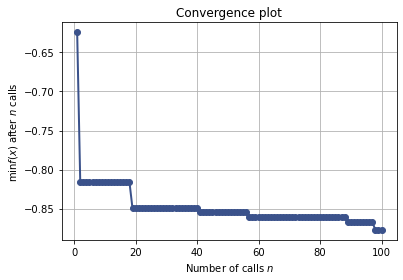

In [15]:
masked_gp = gp_minimize(masked_objective, search_spaces, n_calls=100, random_state=920,acq_func="EI",verbose=True, n_jobs=-1)

"Best score=%.4f" % masked_gp.fun

#---   Decoding feature selection results   ---#
bin_selected_features = bin(masked_gp.x[0])[2:]
for i in range(10-len(bin_selected_features)):
    bin_selected_features = '0' + bin_selected_features

tmp_bin_selected_features = bin(masked_gp.x[1])[2:]
for i in range(10-len(tmp_bin_selected_features)):
    tmp_bin_selected_features = '0' + tmp_bin_selected_features
bin_selected_features = bin_selected_features+ tmp_bin_selected_features

tmp_bin_selected_features = bin(masked_gp.x[2])[2:]
for i in range(10-len(tmp_bin_selected_features)):
    tmp_bin_selected_features = '0' + tmp_bin_selected_features
bin_selected_features = bin_selected_features+ tmp_bin_selected_features

tmp_bin_selected_features = bin(masked_gp.x[3])[2:]
for i in range(7-len(tmp_bin_selected_features)):
    tmp_bin_selected_features = '0' + tmp_bin_selected_features
bin_selected_features = bin_selected_features+ tmp_bin_selected_features

snv_selected = [snv_to_select[i] for i in range(len(snv_to_select)) if bin_selected_features[i] == '1']

snv_selected.append('patientID')

bin_selected_features = bin(masked_gp.x[4])[2:]
for i in range(9-len(bin_selected_features)):
    bin_selected_features = '0' + bin_selected_features


other_feature_selected = [other_feature_to_select[i] for i in range(len(other_feature_to_select)) if bin_selected_features[i] == '1']
other_feature_selected.append('label')
##---   Print parameters   ---##
print("""Best parameters:
        snv_selected = %s
        other_feature_selected = %s
        fc_dropout = %f
        lr = %f
        patience = %d
        num_fc_layers = %d
        head = %d
        trsf_num_layer = %d
        trsf_dropout = %f
        trsf_hidden = %d""" % (snv_selected, other_feature_selected, masked_gp.x[5],masked_gp.x[6], masked_gp.x[7],
                    masked_gp.x[8], masked_gp.x[9], masked_gp.x[10], masked_gp.x[11], masked_gp.x[12]))

from skopt.plots import plot_convergence

fig = plt.figure()
ax1=plot_convergence(masked_gp)
t = time.localtime()
plt.savefig(str(t.tm_year)+'-'+str(t.tm_mon)+'-'+str(t.tm_mday)+'-'+str(t.tm_hour)+'-'+str(t.tm_min)+'AutoTransformer.png')
plt.savefig(str(t.tm_year)+'-'+str(t.tm_mon)+'-'+str(t.tm_mday)+'-'+str(t.tm_hour)+'-'+str(t.tm_min)+'AutoTransformer.eps')

In [16]:
# ---------------------------------------------------#   
#    Parameter Tuning with Bayesian optimization    #
#--------------------------------------------------# 
import os
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'

seed = 1105

num_outer_split = 5

num_output_nodes, num_epochs = 2, 100
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

fc_dropout, lr, patience, num_fc_layers = masked_gp.x[5],masked_gp.x[6], masked_gp.x[7], masked_gp.x[8]
head, trsf_num_layer, trsf_dropout, trsf_hidden = masked_gp.x[9], masked_gp.x[10], masked_gp.x[11], masked_gp.x[12]

new_train_snv = deepcopy(train_snv[snv_selected])
new_train_x = deepcopy(train_x[other_feature_selected])
new_train_x = NewGroupAndExtractSNV(new_train_x, new_train_snv, num_steps)

new_test_snv = deepcopy(test_snv[snv_selected])
new_test_x = deepcopy(test_x[other_feature_selected])
new_test_x = NewGroupAndExtractSNV(new_test_x, new_test_snv, num_steps)

num_inputs_lstm = new_train_x.iloc[0]['snv'].shape[1]
num_feature_not_snv = len(other_feature_selected)-1

num_repeat = 100
frac_val = 0.25
train_all = []
val_all = []
test_all = []
for i in range(num_repeat):
    
    seed = seed + i
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    sub_train_index, sub_val_index = next(StratifiedShuffleSplit(n_splits=1,test_size=frac_val).split(new_train_x,new_train_x['label']))

    #---  Seperate traing set, validation set and test set ---#
    sub_train = Resampler(new_train_x.iloc[sub_train_index][:], new_train_x.iloc[sub_train_index]['label'])
    train_iter = BatchDataGeneration(sub_train, batch_size, shuffle=True)
    val_iter = BatchDataGeneration(new_train_x.iloc[sub_val_index][:], batch_size, shuffle=True)
    test_iter = BatchDataGeneration(new_test_x, batch_size, shuffle=True)
    
    shape = new_train_x['snv'][0].shape
    
    #-----  Instantiate model -----#
    
    model = AutoTransformer(fc_dropout, num_feature_not_snv, num_output_nodes, num_fc_layers, device, 
                                     head, trsf_num_layer, trsf_dropout, trsf_hidden, shape)
    model = model.to(device)
    model.apply(init_weights)
    
    #-----  Loss -----#
    loss = nn.CrossEntropyLoss(reduction="none")
    loss = loss.to(device)

    #--- Define optimizer ---#
    optimizer = torch.optim.Adam(model.parameters(), lr)

    #-----  Instantiate EarlyStopping -----#
    early_stopping = EarlyStopping(patience, verbose=False)

    train_loss, train_acc, train_auc, train_speed, val_loss, val_acc, val_auc = train_evaluate(
        model, train_iter, val_iter, loss, optimizer, early_stopping, num_epochs, device)

    test_loss, test_acc, test_auc = evaluate(model, test_iter, loss, device)

    train_all.append([train_loss, train_acc, train_auc, train_speed])
    val_all.append([val_loss, val_acc, val_auc])
    test_all.append([test_loss, test_acc, test_auc])
    print('-'*20)
    print('num of repeat:', i)
    print('-'*20)
    print(f'On training set: Loss {train_loss:.3f}, Accuracy {train_acc:.3f}, Auc {train_auc:.3f}, {train_speed:.1f} samples/s {str(device)}.')
    print(f'On validation set: Loss {val_loss:.3f}, Accuracy {val_acc:.3f}, Auc {val_auc:.3f}.')
    print(f'On test set: Loss {test_loss:.3f}, Accuracy {test_acc:.3f}, Auc {test_auc:.3f}.')


train_all = np.array(train_all)
val_all = np.array(val_all)
test_all = np.array(test_all)

train_loss, train_acc, train_auc, train_speed = train_all[:,0], train_all[:,1], train_all[:,2], train_all[:,3]
val_loss, val_acc, val_auc = val_all[:,0], val_all[:,1], val_all[:,2]
test_loss, test_acc, test_auc = test_all[:,0], test_all[:,1], test_all[:,2]    
print('-'*20)
print('One layer without smote with mask with early stopping under k-fold cv best model:')
print('-'*20)
print(f'On training set: Loss {train_loss.mean():.3f}, Accuracy {train_acc.mean():.3f}, Auc {train_auc.mean():.3f}, {train_speed.mean():.1f} samples/s {str(device)}.')
print(f'On validation set: Loss {val_loss.mean():.3f}, Accuracy {val_acc.mean():.3f}, Auc {val_auc.mean():.3f}.')
print(f'On test set: Loss {test_loss.mean():.3f}, Accuracy {test_acc.mean():.3f}, Auc {test_auc.mean():.3f}.')

#-----  Save performance -----#
df = (('train_loss', 'train_acc', 'train_auc', 'train_speed', 'val_loss', 'val_acc', 'val_auc', 'test_loss', 'test_acc', 'test_auc'),  
      (train_loss, train_acc, train_auc, train_speed, val_loss, val_acc, val_auc, test_loss, test_acc, test_auc)  
      )
df = pd.DataFrame(df)
t = time.localtime()
file_name = 'AutoTransformer'+str(t.tm_year)+'-'+str(t.tm_mon)+'-'+str(t.tm_mday)+'-'+str(t.tm_hour)+'-'+str(t.tm_min)+'.xlsx' #(t.tm_year)
df.to_excel(file_name,index = False)

--------------------
num of repeat: 0
--------------------
On training set: Loss 0.362, Accuracy 0.955, Auc 0.968, 402.1 samples/s cuda.
On validation set: Loss 0.513, Accuracy 0.800, Auc 0.886.
On test set: Loss 0.570, Accuracy 0.734, Auc 0.798.
--------------------
num of repeat: 1
--------------------
On training set: Loss 0.357, Accuracy 0.955, Auc 0.972, 437.0 samples/s cuda.
On validation set: Loss 0.470, Accuracy 0.850, Auc 0.838.
On test set: Loss 0.589, Accuracy 0.723, Auc 0.748.
--------------------
num of repeat: 2
--------------------
On training set: Loss 0.365, Accuracy 0.962, Auc 0.939, 413.8 samples/s cuda.
On validation set: Loss 0.538, Accuracy 0.775, Auc 0.819.
On test set: Loss 0.555, Accuracy 0.755, Auc 0.770.
--------------------
num of repeat: 3
--------------------
On training set: Loss 0.397, Accuracy 0.923, Auc 0.934, 406.3 samples/s cuda.
On validation set: Loss 0.491, Accuracy 0.825, Auc 0.920.
On test set: Loss 0.582, Accuracy 0.713, Auc 0.705.
------------

--------------------
num of repeat: 34
--------------------
On training set: Loss 0.512, Accuracy 0.808, Auc 0.887, 413.8 samples/s cuda.
On validation set: Loss 0.620, Accuracy 0.650, Auc 0.786.
On test set: Loss 0.618, Accuracy 0.670, Auc 0.736.
--------------------
num of repeat: 35
--------------------
On training set: Loss 0.563, Accuracy 0.744, Auc 0.815, 429.8 samples/s cuda.
On validation set: Loss 0.674, Accuracy 0.550, Auc 0.813.
On test set: Loss 0.646, Accuracy 0.628, Auc 0.718.
--------------------
num of repeat: 36
--------------------
On training set: Loss 0.480, Accuracy 0.833, Auc 0.914, 414.9 samples/s cuda.
On validation set: Loss 0.610, Accuracy 0.650, Auc 0.783.
On test set: Loss 0.617, Accuracy 0.681, Auc 0.735.
--------------------
num of repeat: 37
--------------------
On training set: Loss 0.440, Accuracy 0.865, Auc 0.930, 526.7 samples/s cuda.
On validation set: Loss 0.458, Accuracy 0.850, Auc 0.931.
On test set: Loss 0.568, Accuracy 0.755, Auc 0.773.
--------

--------------------
num of repeat: 68
--------------------
On training set: Loss 0.533, Accuracy 0.795, Auc 0.852, 430.9 samples/s cuda.
On validation set: Loss 0.581, Accuracy 0.675, Auc 0.831.
On test set: Loss 0.638, Accuracy 0.628, Auc 0.716.
--------------------
num of repeat: 69
--------------------
On training set: Loss 0.513, Accuracy 0.808, Auc 0.871, 450.8 samples/s cuda.
On validation set: Loss 0.487, Accuracy 0.825, Auc 0.900.
On test set: Loss 0.649, Accuracy 0.638, Auc 0.730.
--------------------
num of repeat: 70
--------------------
On training set: Loss 0.419, Accuracy 0.910, Auc 0.952, 485.8 samples/s cuda.
On validation set: Loss 0.603, Accuracy 0.700, Auc 0.799.
On test set: Loss 0.635, Accuracy 0.670, Auc 0.766.
--------------------
num of repeat: 71
--------------------
On training set: Loss 0.410, Accuracy 0.904, Auc 0.937, 464.2 samples/s cuda.
On validation set: Loss 0.544, Accuracy 0.775, Auc 0.701.
On test set: Loss 0.614, Accuracy 0.691, Auc 0.726.
--------

In [17]:
t = time.localtime()
print(str(t.tm_hour)+':'+str(t.tm_min))

18:57
